In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv('ushape.csv' , header=None , names= ['X1' , 'X2' , 'Y'])

In [13]:
# df.columns = ['Feature 1' , 'Feature 2' , 'Target']

In [14]:
df.sample(5)

,X1,X2,Y
43,-1.069650,0.136660,0.0
2,0.882490,-0.075756,0.0
77,1.739237,0.459004,1.0
15,-0.366532,1.119716,0.0
95,1.699453,0.587720,1.0


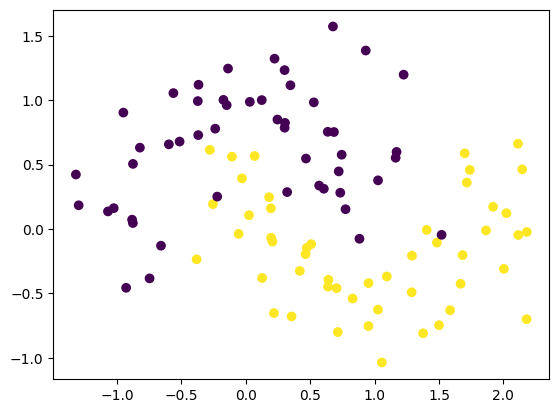

In [16]:
plt.scatter(x = df.iloc[: , 0] , y = df.iloc[: , 1] , c = df.iloc[: , 2])

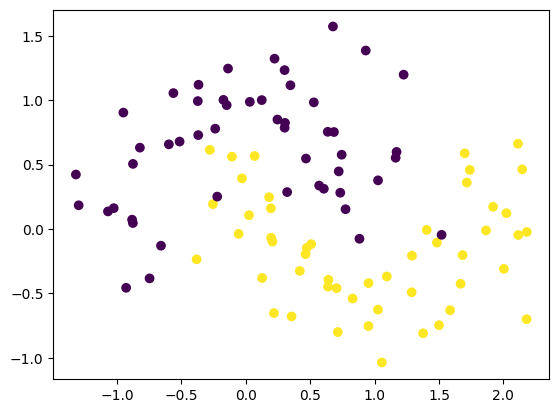

In [15]:
plt.scatter(x = df['X1'] , y = df['X2'] , c = df['Y'])

In [19]:
X= df.iloc[: , 0 : 2].values

In [23]:
y = df.iloc[: , -1].values

In [26]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [27]:
model = Sequential()

model.add(Dense(10 , activation='sigmoid' , input_dim = 2))
model.add(Dense(1 , activation='sigmoid' ))

model.summary()

/home/subhamoy/miniforge3/envs/tf_gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1766587218.370498    1126 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.get_weights()

[array([[ 0.6122113 , -0.6095157 , -0.53143144, -0.44395348, -0.7031788 ,
         -0.5408644 , -0.0712676 ,  0.3394596 ,  0.20242184,  0.5206118 ],
        [-0.6115897 , -0.15220153,  0.5704257 , -0.19141567,  0.2759295 ,
          0.14174038,  0.07384515, -0.29111183, -0.30641332,  0.15542966]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.30378115],
        [ 0.26244956],
        [ 0.44841474],
        [ 0.56227726],
        [-0.49476373],
        [-0.01784098],
        [-0.6421362 ],
        [-0.59714675],
        [-0.01917005],
        [ 0.7064511 ]], dtype=float32),
 array([0.], dtype=float32)]

In [29]:
initial_weights = model.get_weights()

In [32]:
initial_weights[0]

array([[ 0.6122113 , -0.6095157 , -0.53143144, -0.44395348, -0.7031788 ,
        -0.5408644 , -0.0712676 ,  0.3394596 ,  0.20242184,  0.5206118 ],
       [-0.6115897 , -0.15220153,  0.5704257 , -0.19141567,  0.2759295 ,
         0.14174038,  0.07384515, -0.29111183, -0.30641332,  0.15542966]],
      dtype=float32)

In [33]:
initial_weights[1]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [34]:
initial_weights[2]

array([[-0.30378115],
       [ 0.26244956],
       [ 0.44841474],
       [ 0.56227726],
       [-0.49476373],
       [-0.01784098],
       [-0.6421362 ],
       [-0.59714675],
       [-0.01917005],
       [ 0.7064511 ]], dtype=float32)

In [36]:
initial_weights[3]

array([0.], dtype=float32)

In [40]:
initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [38]:
np.zeros(2)

array([0., 0.])

In [39]:
np.zeros(model.get_weights()[0].shape)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [41]:
model.set_weights(initial_weights)

In [42]:
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [43]:
model.compile(loss = 'binary_crossentropy' , optimizer='adam' , metrics=['accuracy'])

In [45]:
history = model.fit(X,y , epochs=100 , validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 360ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss

In [46]:
model.get_weights()

[array([[ 0.4344392 ,  0.4344392 ,  0.4344392 ,  0.4344392 ,  0.4344392 ,
          0.4344392 ,  0.4344392 ,  0.4344392 ,  0.4344392 ,  0.4344392 ],
        [-0.47109318, -0.47109318, -0.47109318, -0.47109318, -0.47109318,
         -0.47109318, -0.47109318, -0.47109318, -0.47109318, -0.47109318]],
       dtype=float32),
 array([-0.13859259, -0.13859259, -0.13859259, -0.13859259, -0.13859259,
        -0.13859259, -0.13859259, -0.13859259, -0.13859259, -0.13859259],
       dtype=float32),
 array([[0.05820339],
        [0.05820339],
        [0.05820339],
        [0.05820339],
        [0.05820339],
        [0.05820339],
        [0.05820339],
        [0.05820339],
        [0.05820339],
        [0.05820339]], dtype=float32),
 array([-0.06807936], dtype=float32)]

In [47]:
from mlxtend.plotting import plot_decision_regions

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


<Axes: >

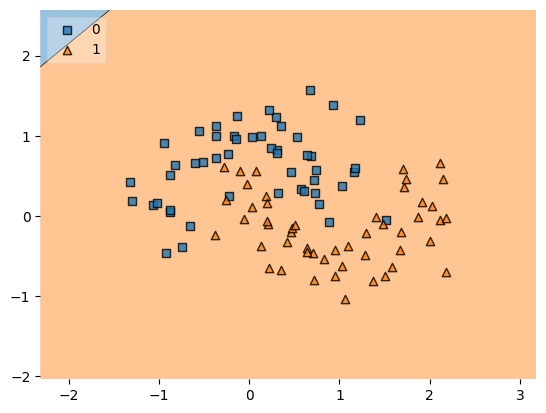

In [48]:
plot_decision_regions(X, y.astype('int') , clf=model , legend = 2)

In [49]:
model2 = Sequential()

model2.add(Dense(1 , activation='sigmoid' , input_dim = 2))
model2.add(Dense(1 , activation='sigmoid' ))

model2.summary()

/home/subhamoy/miniforge3/envs/tf_gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (20.00 B)

 Trainable params: 5 (20.00 B)

 Non-trainable params: 0 (0.00 B)

In [72]:
initial_wt = model2.get_weights()

In [73]:
initial_wt

[array([[0.9740478 ],
        [0.52311313]], dtype=float32),
 array([0.], dtype=float32),
 array([[-0.8943862]], dtype=float32),
 array([0.], dtype=float32)]

In [74]:
initial_wt[0] = np.zeros(model2.get_weights()[0].shape)
initial_wt[1] = np.zeros(model2.get_weights()[1].shape)
initial_wt[2] = np.zeros(model2.get_weights()[2].shape)

In [75]:
initial_wt[3] = np.zeros(model2.get_weights()[3].shape)

In [76]:
model2.set_weights(initial_wt)

In [77]:
model2.compile(loss = 'binary_crossentropy' , optimizer='adam' , metrics=['accuracy'])

In [78]:
history1= model2.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step - accuracy: 0.4500 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4250 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

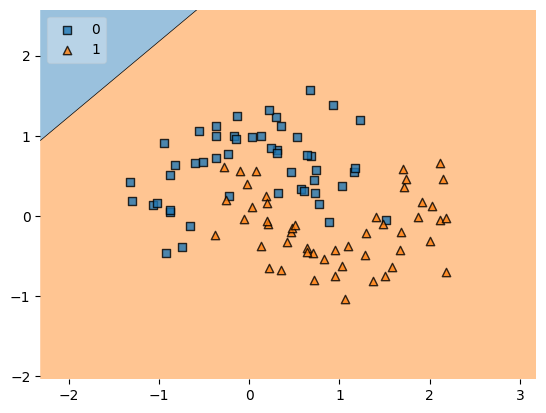

In [79]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model2, legend=2)